
Figure S15: Single-causal variant colocalization. For each pcGene or eGene phenotype and GWAS trait, Posterior probability of colocalization (PPH4) between GWAS and QTL phenotypes assuming a single-causal variant (coloc.abf) vs maximum PPH4 over all credible sets for colocalization with run SuSiE, allowing for multiple causal variants (coloc.susie). Dotted red lines are the PPH4=0.75 cutoff used for a significant colocalization. Boxes show the number and % or GWAS-phenotype pairs in each quadrant. 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 


# get outputs from a config file
import yaml
susie_config_path= '/home/klawren/oak/pcqtls/config_old/main_pcqtl.yaml'
with open(susie_config_path, 'r') as f:
    susie_config = yaml.safe_load(f)

no_susie_config_path= '/home/klawren/oak/pcqtls/config_old/no_susie.yaml'
with open(no_susie_config_path, 'r') as f:
    no_susie_config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import * 
from group_signals import load_gwas_coloc

%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

In [ ]:
no_susie_gwas_coloc = load_gwas_coloc(no_susie_config)
susie_gwas_coloc = load_gwas_coloc(susie_config)

getting files in directory: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_False
found 1482 files
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_False/Skin_Not_Sun_Exposed_Suprapubic/Skin_Not_Sun_Exposed_Suprapubic.v8.GEFOS_Forearm.gwas_coloc.txt
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_False/Skin_Not_Sun_Exposed_Suprapubic/Skin_Not_Sun_Exposed_Suprapubic.v8.GPC-NEO-NEUROTICISM.gwas_coloc.txt
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_False/Skin_Not_Sun_Exposed_Suprapubic/Skin_Not_Sun_Exposed_Suprapubic.v8.EGG_Pubertal_growth_10F.gwas_coloc.txt
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_False/Skin_Not_Sun_Exposed_Suprapubic/Skin_Not_Sun_Exposed_Suprapubic.v8.PGC_ASD_2017_CEU.gwas_coloc.txt
File is empty: /home/klawren/oak/pcqtls/output/proteincoding_main/coloc/gwas_susie_False/Skin_Not_Sun_Exposed_Suprapubic/S

In [4]:
susie_qtl_grouped = susie_gwas_coloc.groupby(['gwas_id', 'qtl_id', 'tissue_id', 'cluster_id']).agg({'PP.H4.abf': 'max'}).reset_index()
susie_qtl_grouped['colocalized'] = susie_qtl_grouped['PP.H4.abf'] > 0.75
no_susie_qtl_grouped = no_susie_gwas_coloc.groupby(['gwas_id', 'qtl_id', 'tissue_id']).agg({'PP.H4.abf': 'max'}).reset_index()
no_susie_qtl_grouped['colocalized'] = no_susie_qtl_grouped['PP.H4.abf'] > 0.75

qtl_grouped = pd.merge(susie_qtl_grouped, no_susie_qtl_grouped, on=['gwas_id', 'qtl_id', 'tissue_id'], how='left', suffixes=('_susie', '_abf'))
qtl_grouped['qtl_type'] = np.where(qtl_grouped['qtl_id'].str.contains('pc'), 'pcqtl', 'eqtl')

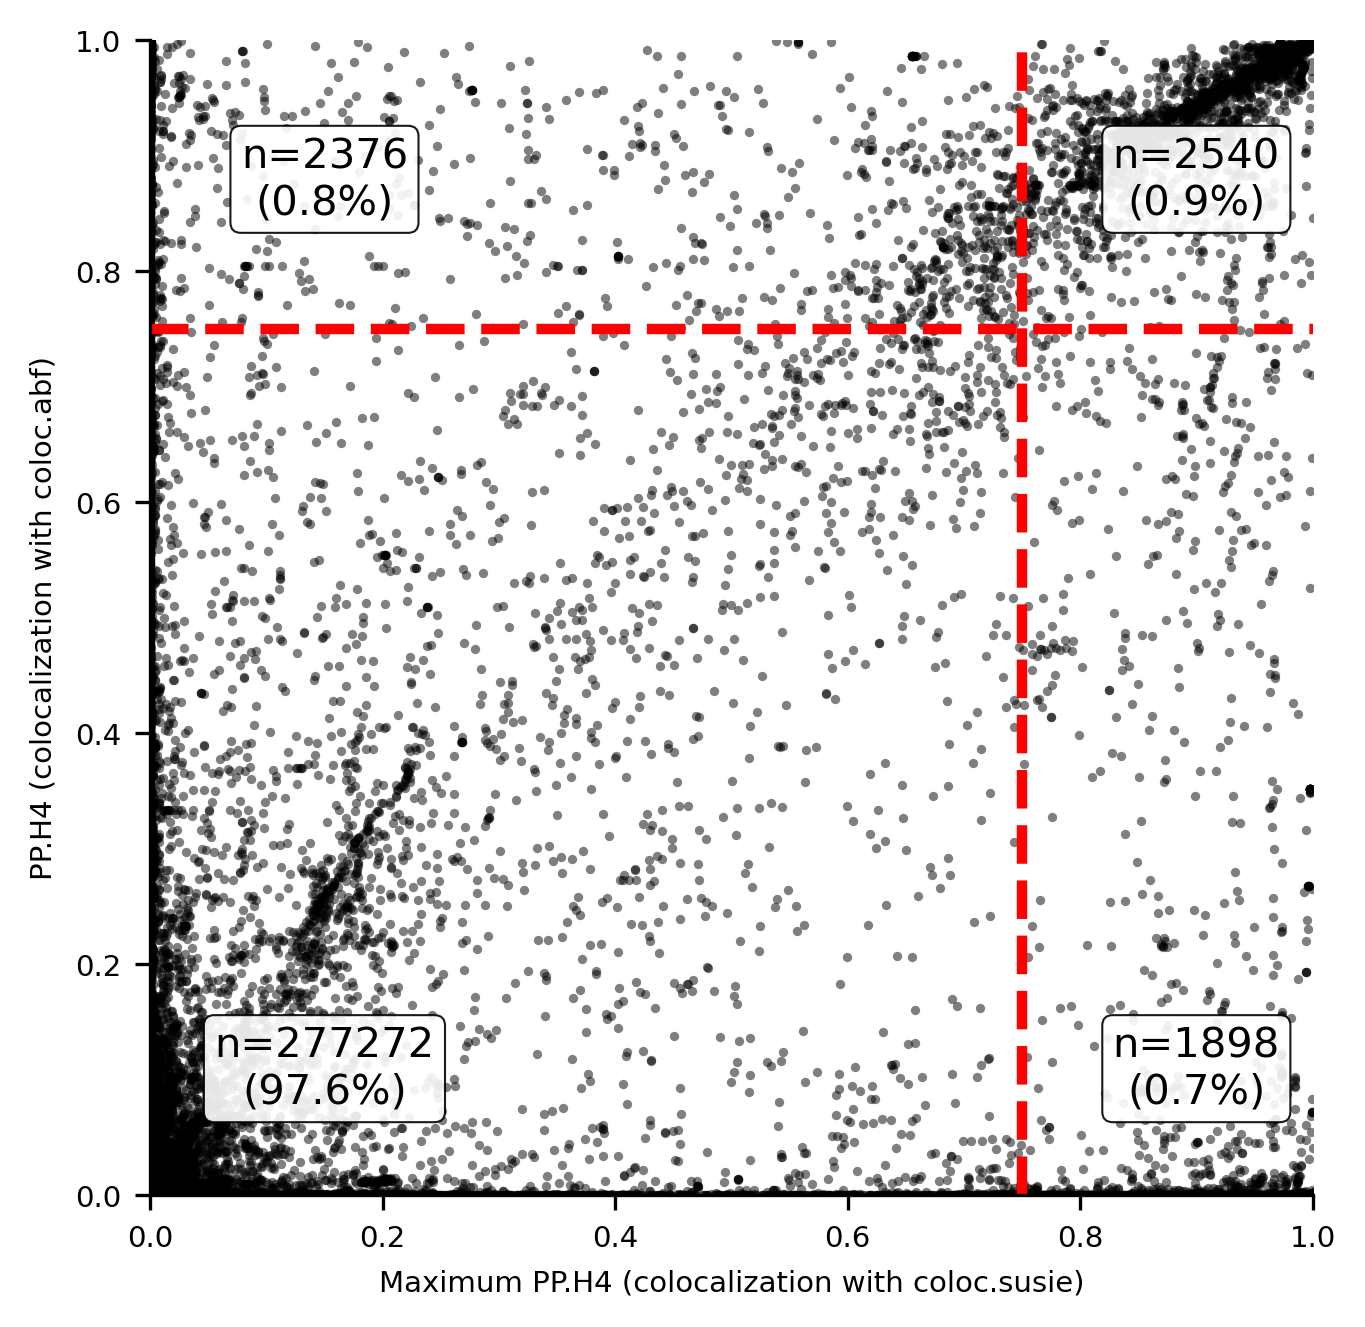

In [21]:
# Define quadrant masks based on the 0.75 lines
q1 = (qtl_grouped['PP.H4.abf_susie'] > 0.75) & (qtl_grouped['PP.H4.abf_abf'] > 0.75)    # upper right
q2 = (qtl_grouped['PP.H4.abf_susie'] <= 0.75) & (qtl_grouped['PP.H4.abf_abf'] > 0.75)   # upper left
q3 = (qtl_grouped['PP.H4.abf_susie'] <= 0.75) & (qtl_grouped['PP.H4.abf_abf'] <= 0.75)  # lower left
q4 = (qtl_grouped['PP.H4.abf_susie'] > 0.75) & (qtl_grouped['PP.H4.abf_abf'] <= 0.75)   # lower right

n_q1 = q1.sum()
n_q2 = q2.sum()
n_q3 = q3.sum()
n_q4 = q4.sum()
n_total = len(qtl_grouped)

pct_q1 = 100 * n_q1 / n_total
pct_q2 = 100 * n_q2 / n_total
pct_q3 = 100 * n_q3 / n_total
pct_q4 = 100 * n_q4 / n_total

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
sns.scatterplot(qtl_grouped, x='PP.H4.abf_susie', y='PP.H4.abf_abf', s=5, alpha=0.5, linewidth=0, color='black', ax=ax)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Maximum PP.H4 (colocalization with coloc.susie)')
ax.set_ylabel('PP.H4 (colocalization with coloc.abf)')
ax.axhline(0.75, color='red', linestyle='--', linewidth=2.5)
ax.axvline(0.75, color='red', linestyle='--', linewidth=2.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Annotate the number of points in each quadrant with alpha=0.5 boxes and non-bold text
bbox_props = dict(boxstyle='round,pad=0.25', fc='white', ec='black', linewidth=0.5, alpha=0.9)
ax.text(0.9, 0.85, f'n={n_q1}\n({pct_q1:.1f}%)', transform=ax.transAxes, fontsize=10, ha='center', bbox=bbox_props)  # upper right
ax.text(0.15, 0.85, f'n={n_q2}\n({pct_q2:.1f}%)', transform=ax.transAxes, fontsize=10, ha='center', bbox=bbox_props)   # upper left
ax.text(0.15, 0.08, f'n={n_q3}\n({pct_q3:.1f}%)', transform=ax.transAxes, fontsize=10, ha='center', bbox=bbox_props)   # lower left
ax.text(0.9, 0.08, f'n={n_q4}\n({pct_q4:.1f}%)', transform=ax.transAxes, fontsize=10, ha='center', bbox=bbox_props)  # lower right


plt.savefig(f"{susie_config['working_dir']}/workflow/supplemental_figures/figures/figure_s15.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [7]:
eqtl_grouped = qtl_grouped[qtl_grouped['qtl_type']=='eqtl'].groupby(['gwas_id', 'tissue_id', 'cluster_id']).agg({'PP.H4.abf_susie': 'max', 'PP.H4.abf_abf': 'max', 'colocalized_susie': 'any', 'colocalized_abf': 'any'}).reset_index()
pcqtl_grouped = qtl_grouped[qtl_grouped['qtl_type']=='pcqtl'].groupby(['gwas_id', 'tissue_id', 'cluster_id']).agg({'PP.H4.abf_susie': 'max', 'PP.H4.abf_abf': 'max', 'colocalized_susie': 'any', 'colocalized_abf': 'any'}).reset_index()

qtl_type_split = pd.merge(eqtl_grouped, pcqtl_grouped, on=['gwas_id', 'tissue_id', 'cluster_id'], how='left', suffixes=('_eqtl', '_pcqtl'))
novel_susie = qtl_type_split[(qtl_type_split['PP.H4.abf_susie_pcqtl'] > 0.75) & (qtl_type_split['PP.H4.abf_susie_eqtl'] < 0.75)]
novel_abf = qtl_type_split[(qtl_type_split['PP.H4.abf_abf_pcqtl'] > 0.75) & (qtl_type_split['PP.H4.abf_abf_eqtl'] < 0.75)]

print('Number of novel pcQTLs with susie: {}'.format(len(novel_susie)))
print('Number of novel pcQTLs without susie: {}'.format(len(novel_abf)))

Number of novel pcQTLs with susie: 577
Number of novel pcQTLs without susie: 519
